## Runge-Kutta Methods
1. [Runge–Kutta methods](https://en.wikipedia.org/wiki/Runge%E2%80%93Kutta_methods)
2. [List of Runge–Kutta methods](https://en.wikipedia.org/wiki/List_of_Runge%E2%80%93Kutta_methods)
Butcher tableau for an **explicit** Runge-Kutta scheme 
\begin{array}
{c|ccccc}
0\\
c_2 & a_{21}\\
c_3 & a_{31} &a_{32} \\
\vdots & \vdots & & \ddots\\
c_s& a_{s1}& a_{s2} & \cdots & a_{s,s-1}\\
\hline
& b_1 &b_2 &\cdots & b_{s-1} & b_s \\ 
\end{array}
Then
$$
    y_{n+1} = y_n+h\sum_{i=1}^{s}b_i k_i
$$
where
\begin{align}
    k_1 &= f(t_n,y_n),\cr
    k_2 &= f(t_n+c_2h,y_n+h(a_{21}k_1)),\cr
    k_3 &= f(t_n+c_3h,y_n+h(a_{31}k_1+a_{32}k_2)),\cr
    &\vdots\cr
    k_s &= f(t_n+c_sh,y_n+h(a_{s1}k_1+a_{s2}k_2+\cdots+a_{s,s-1}k_{s-1}))\cr
\end{align}

## General Purpose Explicit Runge-Kutta Method

### Imports

In [1]:
import numpy as np, numpy.linalg as LA, math
from math import pi as π
import matplotlib.pyplot as plt

In [2]:
def rk(fun,t_span,y0,n,tableau=None,verbose=False):
    """
    fun: vector field function for ODE
    t_span: array of length 2 specify the start and end time
    y0: array specifying an initial condition
    n: number of fixed steps to take
    tableau: tuple (a,b,c) describing the Butcher Tableau for the method
    """
    y0 = np.array(y0)
    t = np.linspace(t_span[0],t_span[1],n+1)
    h = (t_span[1]-t_span[0])/n
    y = np.empty((n+1,y0.size))
    y[0] = y0
    if tableau is None:
        s = 4
        a = np.array([[1/2,0,0],[0,1/2,0],[0,0,1]])
        b = np.array([1/6,1/3,1/3,1/6])
        c = np.array([0,1/2,1/2,1])
    else:
        a,b,c = tableau
        s = len(b)
    if verbose:
        print('s = %d' %s)
        print('n = %d' %n)
        print('h = %.4f' %h)
        print('a:',a)
        print('b:',b)
        print('c:',c)
    K = np.empty(s)
    for i in range(n):
        K[0] = fun(t[i]+c[0]*h,y[i].squeeze())
        for j in range(1,s):
            ttmp = t[i] + c[j]*h
            ytmp = y[i] + h*K[:j]@a[j-1,:j]
            K[j] = fun(ttmp,ytmp.squeeze())
        y[i+1] = y[i] + h * b@K
    return t, y

In [22]:
fun = lambda t, y: -2.*y
t0,t1 = 0,1
y0 = 1

nsteps = 50
h = (t1-t0)/nsteps

t_span = [t0,t1]

In [23]:
tout,yout = rk(fun,t_span,y0,nsteps)
yout = yout.squeeze()
math.exp(-2.*t1)-yout[-1],(math.exp(-2.*t1)-yout[-1])/h**4

(np.float64(-5.970120842135884e-09), np.float64(-0.037313255263349276))

In [24]:
nsteps = 100
h = (t1-t0)/nsteps
tout,yout = rk(fun,t_span,y0,nsteps)
yout = yout.squeeze()
math.exp(-2.*t1)-yout[-1],(math.exp(-2.*t1)-yout[-1])/h**4

(np.float64(-3.669607950840259e-10), np.float64(-0.03669607950840259))

In [26]:
tol = 1e-12
h = (tol/0.04)**(0.25)
h,1/h

(0.0022360679774997894, 447.213595499958)

In [27]:
nsteps = 448
h = (t1-t0)/nsteps
tout,yout = rk(fun,t_span,y0,nsteps)
yout = yout.squeeze()
math.exp(-2.*t1)-yout[-1],(math.exp(-2.*t1)-yout[-1])/h**4

(np.float64(-8.992251387951455e-13), np.float64(-0.03622267302125693))

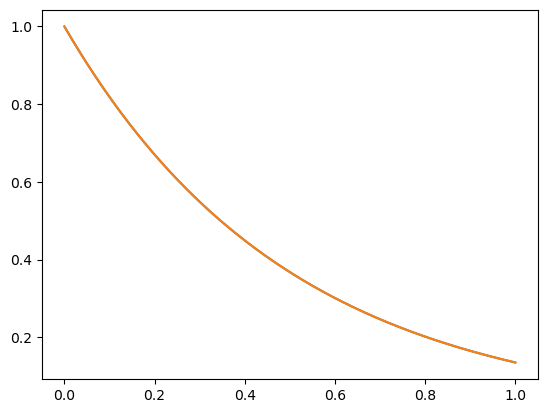

In [28]:
plt.plot(tout,np.exp(-2*tout))
plt.plot(tout,yout)

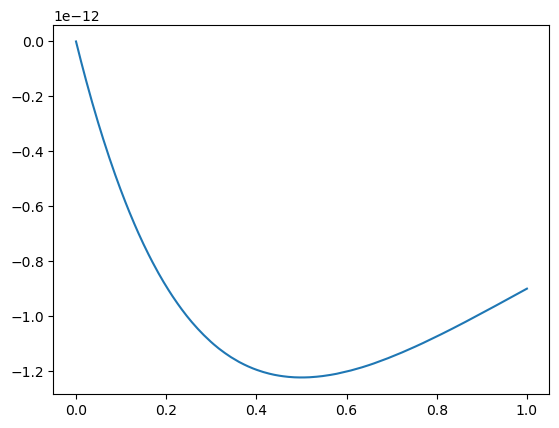

In [30]:
plt.plot(tout,np.exp(-2*tout)-yout)

### Kutta's Third Order Method
\begin{array}
{c|ccc}
0\\
1/2 & 1/2\\
1 & -1 &2 \\
\hline
& 1/6 & 2/3  & 1/6 \\ 
\end{array}

In [31]:
a = np.array([[0.5,0],[-1,2]])
b = np.array([1/6,2/3,1/6])
c = np.array([0,0.5,1])
tableau = (a,b,c)

In [34]:
nsteps = 50
h = (t1-t0)/nsteps
tout,yout = rk(fun,t_span,y0,nsteps,tableau=tableau)
(math.exp(-2)-yout[-1])/h**3

array([0.0931591])

In [35]:
nsteps = 100
h = (t1-t0)/nsteps
tout,yout = rk(fun,t_span,y0,nsteps,tableau=tableau)
(math.exp(-2)-yout[-1])/h**3

array([0.09167917])

### Initial-Value Problem
$$
    {dy\over dt}= -2y^3 + \cos(ty) - \sin(t)\qquad y(t_0) = y_0
$$
Estimate $y(t_1)$.

In [36]:
fun = lambda t,y: -2*y**3 + np.cos(y*t) - np.sin(t)
t0,t1 = 0,1
y0 = 1.

t_span = [t0,t1]

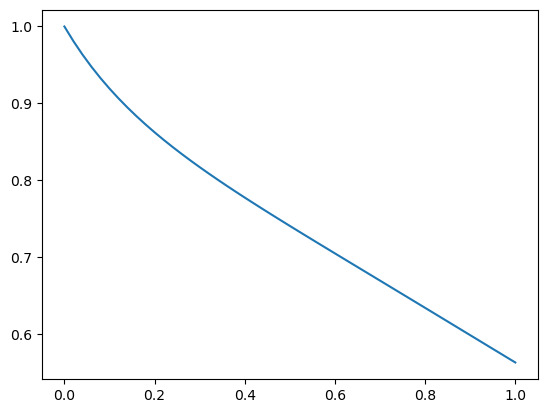

In [37]:
nsteps = 50
tout,yout = rk(fun,t_span,y0,nsteps,tableau=tableau)
plt.plot(tout,yout)

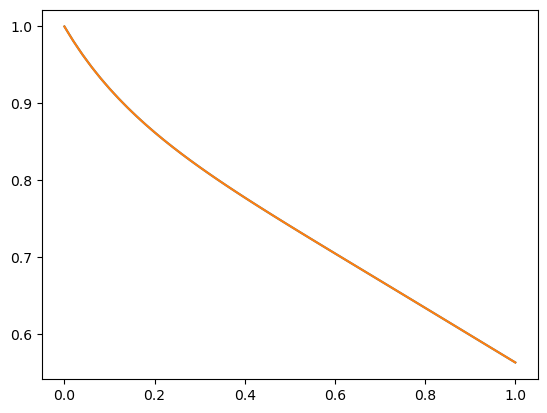

In [38]:
tout1,yout1=tout,yout
nsteps = 100
tout2,yout2 = rk(fun,t_span,y0,nsteps,tableau=tableau)
plt.plot(tout1,yout1,tout2,yout2)

In [39]:
yout2[-1]-yout1[-1]

array([1.94714139e-07])

In [41]:
h1 = 1/50
C = (yout2[-1]-yout1[-1])*8/(7*h1**3)
C

array([0.02781631])

In [43]:
hopt = (tol/C)**(1/3)
hopt,1/hopt

(array([0.00033004]), array([3029.93386938]))

In [44]:
nsteps = 3030
tout3,yout3 = rk(fun,t_span,y0,nsteps,tableau=tableau)

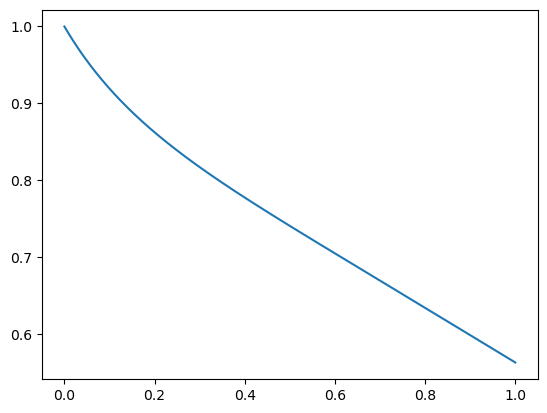

In [45]:
plt.plot(tout3,yout3)

In [46]:
nsteps = 6060
tout4,yout4 = rk(fun,t_span,y0,nsteps,tableau=tableau)

In [47]:
yout4[-1]-yout3[-1]

array([7.92366173e-13])

## Analysis of the third order method

$\newcommand{\dt}{\Delta t}$
$\newcommand{\dy}{\Delta y}$
$\newcommand{\args}{t+\tau\dt,y+\tau\dy}$
We showed that if $f$ is sufficiently smooth, suppressing the arguments $(t,y)$ on the right-hand side,
\begin{align*}
    f(t+\dt,y+\dy) &= f +  f_t\dt + f_y\dy + {f_{tt}\over2}\dt^2 + f_{ty}\dt\dy + {f_{yy}\over 2}\dy^2\cr
    &\quad+ {f_{ttt}\over 6}\dt^3 + {f_{tty}\over 2}\dt^2\dy +  {f_{tyy}\over 2}\dt\dy^2 + {f_{yyy}\over 6}\dy^3\cr
    &\quad+ {f_{tttt}\over 24}\dt^4 + {f_{ttty}\over 6}\dt^3\dy + {f_{ttyy}\over4}\dt^2\dy^2 + {f_{tyyy}\over 6}\dt\dy^3 + {f_{yyyy}\over24}\dy^4\cr
    &\quad+ O(h^5)\cr
\end{align*}

$\newcommand{\dt}{\Delta t}$
$\newcommand{\dy}{\Delta y}$
$\newcommand{\args}{t+\tau\dt,y+\tau\dy}$
\begin{align*}
    f(t+\dt,y+\dy) &= f +  f_t\dt + f_y\dy + {f_{tt}\over2}\dt^2 + f_{ty}\dt\dy + {f_{yy}\over 2}\dy^2\cr
    &\quad+ {f_{ttt}\over 6}\dt^3 + {f_{tty}\over 2}\dt^2\dy +  {f_{tyy}\over 2}\dt\dy^2 + {f_{yyy}\over 6}\dy^3\cr
    &\quad+ \ldots\cr
\end{align*}

But
then
\begin{align*}
y(t+h) &= y(t) + fh + \left({ f_t + f_{y}f\over 2}\right)h^2 + \left({f_{tt} + 2 f_{ty}f + f_{yy}f^2 + f_{t}f_{y} + f_{y}^2 f\over 6}\right)h^3
    +O(h^4)\cr
\end{align*}